In [8]:
import warnings
warnings.filterwarnings('ignore')

2007 年青少年目前飲酒的比例是否不同於基準值 $p_{0} = 0.35$？

2007 年青少年的平均體重是否不同於基準值 $\mu_{0} = 68.0$ 公斤？

In [9]:
import pandas as pd

# 1. 讀取原始資料 (使用相對路徑，這樣組員下載也能跑)
# 假設你的 Notebook 存放在 notebooks/ 資料夾下
df = pd.read_csv('../data/raw/YRBS_2007.csv')

# 2. 資料檢查：看看這兩個變數有多少缺失值
print(df[['CurrentAlcoholUse', 'HowMuchDoYouWeighWithoutShoesInKG']].isnull().sum())

# 3. 重編碼 CurrentAlcoholUse (定義成功與失敗)
# 依照手冊：2-7 為成功(1), 1 為失敗(0)
df['alcohol_success'] = df['CurrentAlcoholUse'].apply(lambda x: 1 if 2 <= x <= 7 else (0 if x == 1 else None))

CurrentAlcoholUse                    1372
HowMuchDoYouWeighWithoutShoesInKG     979
dtype: int64


In [10]:
# 建立一個清理後的 DataFrame，排除這兩個欄位的缺失值
df_cleaned = df.dropna(subset=['CurrentAlcoholUse', 'HowMuchDoYouWeighWithoutShoesInKG']).copy()

# 確認清理後的樣本數 (這是作業要求的 Final sample size)
print(f"原始資料筆數: {len(df)}")
print(f"清理後有效樣本數: {len(df_cleaned)}")

原始資料筆數: 14041
清理後有效樣本數: 11843


In [11]:
# 執行重編碼：把 2-7 設為 1 (Success)，把 1 設為 0 (Failure)
df_cleaned['alcohol_binary'] = df_cleaned['CurrentAlcoholUse'].apply(lambda x: 1 if 2 <= x <= 7 else 0)

# 檢查重編碼後的結果
print(df_cleaned['alcohol_binary'].value_counts())

alcohol_binary
0    6449
1    5394
Name: count, dtype: int64


In [12]:
# 將清理後的資料存成新檔案
df_cleaned.to_csv('../data/processed/yrbs_cleaned.csv', index=False)

次數分配：
alcohol_binary
0    6449
1    5394
Name: count, dtype: int64

百分比分配：
alcohol_binary
0    0.544541
1    0.455459
Name: proportion, dtype: float64


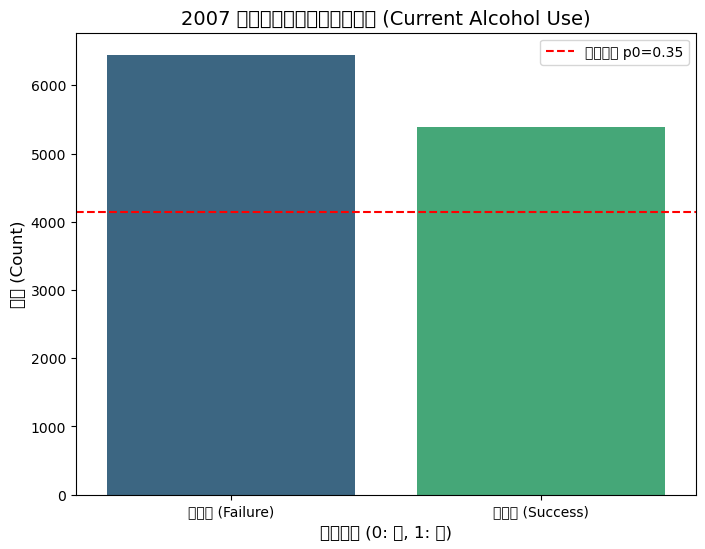

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 計算頻率與比例
alcohol_counts = df_cleaned['alcohol_binary'].value_counts().sort_index()
alcohol_perc = df_cleaned['alcohol_binary'].value_counts(normalize=True).sort_index()

print("次數分配：")
print(alcohol_counts)
print("\n百分比分配：")
print(alcohol_perc)

# 2. 繪製長條圖
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='alcohol_binary', data=df_cleaned, palette='viridis')

# 3. 在圖上加上標籤與標題
plt.title('2007 年青少年目前飲酒行為分佈 (Current Alcohol Use)', fontsize=14)
plt.xlabel('飲酒狀態 (0: 否, 1: 是)', fontsize=12)
plt.ylabel('人數 (Count)', fontsize=12)
plt.xticks([0, 1], ['無飲酒 (Failure)', '有飲酒 (Success)'])

# 4. 畫出一條紅色的基準線 (p0 = 0.35) 供視覺參考
# 注意：這裡畫的是比例線，如果 y 軸是人數，需轉換
total_n = len(df_cleaned)
plt.axhline(y=total_n * 0.35, color='red', linestyle='--', label='基準比例 p0=0.35')
plt.legend()

# 5. 儲存圖檔 (符合作業規範存入 outputs/figures/)
plt.savefig('../outputs/figures/alcohol_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()